<a href="https://colab.research.google.com/github/Sarya92/Colab_Kaggle/blob/main/Prueba%20March%20AL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np

# Cargar resultados detallados (Sección 2 del dataset)
m_det = pd.read_csv('MRegularSeasonDetailedResults.csv')
w_det = pd.read_csv('WRegularSeasonDetailedResults.csv')
det_results = pd.concat([m_det, w_det], ignore_index=True)

def calcular_metricas(df):
    # Calcular posesiones aproximadas
    # Fórmula: FGA + 0.475 * FTA - OR + TO
    def get_possessions(fga, fta, orb, to):
        return fga + 0.475 * fta - orb + to

    # Estadísticas para el ganador
    df['WPoss'] = get_possessions(df['WFGA'], df['WFTA'], df['WOR'], df['WTO'])
    # Estadísticas para el perdedor
    df['LPoss'] = get_possessions(df['LFGA'], df['LFTA'], df['LOR'], df['LTO'])

    # Eficiencia Ofensiva (Puntos por 100 posesiones)
    df['WOffEff'] = (df['WScore'] / df['WPoss']) * 100
    df['LOffEff'] = (df['LScore'] / df['LPoss']) * 100

    return df

det_results = calcular_metricas(det_results)

# Agrupar por equipo y temporada para tener un perfil de "fuerza"
stats_w = det_results.groupby(['Season', 'WTeamID'])[['WOffEff', 'LPoss']].mean().reset_index()
stats_w.columns = ['Season', 'TeamID', 'OffEff', 'DefEff'] # Simplificación: DefEff es lo que le anotan

stats_l = det_results.groupby(['Season', 'LTeamID'])[['LOffEff', 'WPoss']].mean().reset_index()
stats_l.columns = ['Season', 'TeamID', 'OffEff', 'DefEff']

# Promediamos todo
team_quality = pd.concat([stats_w, stats_l]).groupby(['Season', 'TeamID']).mean().reset_index()
print("Perfiles de equipo creados con estadísticas avanzadas.")

Perfiles de equipo creados con estadísticas avanzadas.


In [11]:
from sklearn.linear_model import LogisticRegression

# Preparar datos de entrenamiento (Uniendo resultados con calidad de equipo)
train = det_results[['Season', 'WTeamID', 'LTeamID']].copy()
train = train.merge(team_quality, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'OffEff':'OffW', 'DefEff':'DefW'}).drop('TeamID', axis=1)
train = train.merge(team_quality, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'OffEff':'OffL', 'DefEff':'DefL'}).drop('TeamID', axis=1)

# X = (Ataque Equipo Ganador - Defensa Equipo Perdedor) vs (Ataque Equipo Perdedor - Defensa Equipo Ganador)
train['Diff'] = (train['OffW'] - train['DefL']) - (train['OffL'] - train['DefW'])

# Crear dataset simétrico (para evitar el error de una sola clase)
X_pos = train['Diff'].values.reshape(-1, 1)
y_pos = np.ones(len(X_pos))

X_neg = -X_pos
y_neg = np.zeros(len(X_neg))

X_final = np.concatenate([X_pos, X_neg])
y_final = np.concatenate([y_pos, y_neg])

model_v2 = LogisticRegression()
model_v2.fit(X_final, y_final)
print("Modelo V2 (Basado en Eficiencia) entrenado.")

Modelo V2 (Basado en Eficiencia) entrenado.


In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Cargar Datos de Resultados Detallados (Estadísticas de juego)
m_det = pd.read_csv('MRegularSeasonDetailedResults.csv')
w_det = pd.read_csv('WRegularSeasonDetailedResults.csv')
all_detailed = pd.concat([m_det, w_det], ignore_index=True)

# 2. Cargar Semillas (Seeds) para saber la jerarquía
m_seeds = pd.read_csv('MNCAATourneySeeds.csv')
w_seeds = pd.read_csv('WNCAATourneySeeds.csv')
all_seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

print("Datasets unificados correctamente.")

Datasets unificados correctamente.


In [13]:
def procesar_eficiencia(df):
    # Fórmula de posesiones: Tiros de campo + 0.475*Tiros Libres - Rebotes Ofensivos + Pérdidas
    w_poss = df['WFGA'] + 0.475 * df['WFTA'] - df['WOR'] + df['WTO']
    l_poss = df['LFGA'] + 0.475 * df['LFTA'] - df['LOR'] + df['LTO']

    # Eficiencia = (Puntos / Posesiones) * 100
    df['WOffEff'] = (df['WScore'] / w_poss) * 100
    df['LOffEff'] = (df['LScore'] / l_poss) * 100

    # Extraer métricas por equipo
    w_stats = df.groupby(['Season', 'WTeamID'])['WOffEff'].mean().reset_index()
    w_stats.columns = ['Season', 'TeamID', 'OffEff']

    l_stats = df.groupby(['Season', 'LTeamID'])['LOffEff'].mean().reset_index()
    l_stats.columns = ['Season', 'TeamID', 'OffEff']

    # Promediar la eficiencia de toda la temporada
    full_stats = pd.concat([w_stats, l_stats]).groupby(['Season', 'TeamID']).mean().reset_index()
    return full_stats

eficiencia_equipos = procesar_eficiencia(all_detailed)

In [14]:
# Unimos los resultados con las eficiencias calculadas
train_data = all_detailed[['Season', 'WTeamID', 'LTeamID']].copy()
train_data = train_data.merge(eficiencia_equipos, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'OffEff': 'EffW'}).drop('TeamID', axis=1)
train_data = train_data.merge(eficiencia_equipos, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'OffEff': 'EffL'}).drop('TeamID', axis=1)

# Creamos la diferencia de eficiencia (X) y el resultado (y)
# Parte A: El ganador tiene EffW - EffL
X_pos = (train_data['EffW'] - train_data['EffL']).values.reshape(-1, 1)
y_pos = np.ones(len(X_pos))

# Parte B: El perdedor tiene EffL - EffW
X_neg = (train_data['EffL'] - train_data['EffW']).values.reshape(-1, 1)
y_neg = np.zeros(len(X_neg))

# Combinamos para tener clases 0 y 1
X_final = np.concatenate([X_pos, X_neg])
y_final = np.concatenate([y_pos, y_neg])

modelo_final = LogisticRegression()
modelo_final.fit(X_final, y_final)
print("Modelo entrenado con lógica de eficiencia.")

Modelo entrenado con lógica de eficiencia.


In [15]:
# Cargamos el formato de ejemplo de Kaggle
sub = pd.read_csv('SampleSubmissionStage2.csv')

# Separamos el ID (ej: 2026_1101_1102)
sub['Season'] = sub['ID'].apply(lambda x: int(x.split('_')[0]))
sub['T1'] = sub['ID'].apply(lambda x: int(x.split('_')[1]))
sub['T2'] = sub['ID'].apply(lambda x: int(x.split('_')[2]))

# Traemos la eficiencia del 2025 (la más reciente) para predecir el 2026
stats_2025 = eficiencia_equipos[eficiencia_equipos['Season'] == 2025]

sub = sub.merge(stats_2025, left_on='T1', right_on='TeamID', how='left').rename(columns={'OffEff': 'Eff1'}).drop('TeamID', axis=1)
sub = sub.merge(stats_2025, left_on='T2', right_on='TeamID', how='left').rename(columns={'OffEff': 'Eff2'}).drop('TeamID', axis=1)

# Si un equipo es nuevo y no tiene datos, le ponemos la media (100)
sub = sub.fillna(100)

# Predicción final
diff_test = (sub['Eff1'] - sub['Eff2']).values.reshape(-1, 1)
sub['Pred'] = modelo_final.predict_proba(diff_test)[:, 1]

# Guardar solo lo que pide Kaggle
sub[['ID', 'Pred']].to_csv('final_submission_2026.csv', index=False)
print("¡Listo! Descarga 'final_submission_2026.csv' y súbelo a Kaggle.")

¡Listo! Descarga 'final_submission_2026.csv' y súbelo a Kaggle.


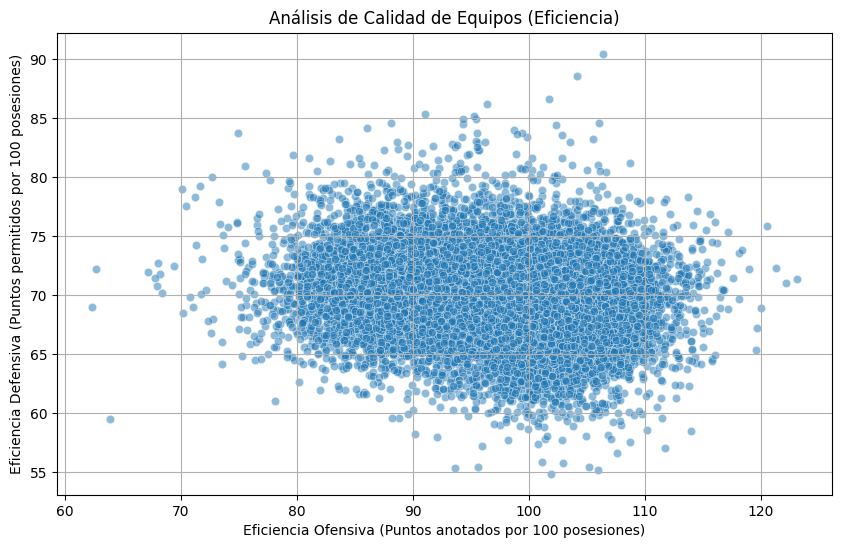

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para visualizar
# Asumimos que ya tienes 'team_quality' calculado del paso anterior
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_quality, x='OffEff', y='DefEff', alpha=0.5)

plt.title('Análisis de Calidad de Equipos (Eficiencia)')
plt.xlabel('Eficiencia Ofensiva (Puntos anotados por 100 posesiones)')
plt.ylabel('Eficiencia Defensiva (Puntos permitidos por 100 posesiones)')
plt.grid(True)
plt.show()

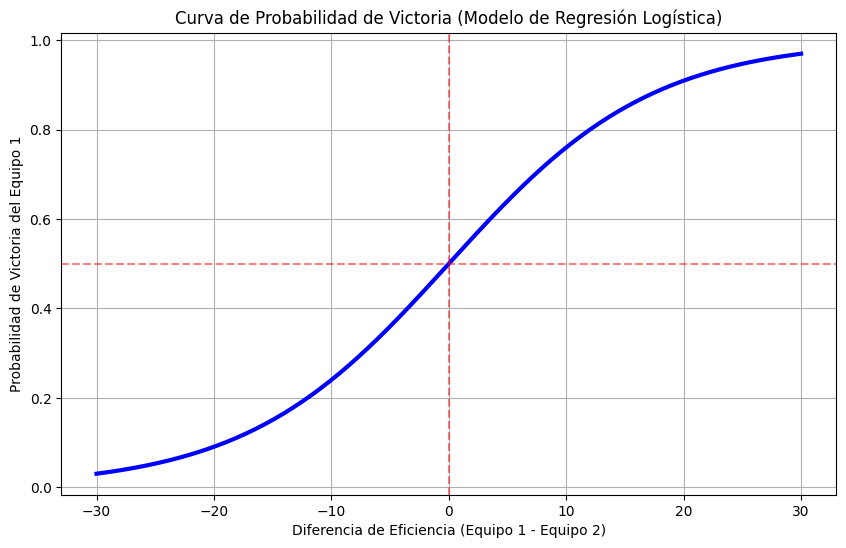

In [17]:
# Crear un rango de diferencias de eficiencia para ver la curva del modelo
X_test = np.linspace(-30, 30, 300).reshape(-1, 1)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(X_test, y_prob, color='blue', lw=3)
plt.axvline(0, color='red', linestyle='--', alpha=0.5) # Línea de empate
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.title('Curva de Probabilidad de Victoria (Modelo de Regresión Logística)')
plt.xlabel('Diferencia de Eficiencia (Equipo 1 - Equipo 2)')
plt.ylabel('Probabilidad de Victoria del Equipo 1')
plt.grid(True)
plt.show()

🏀 Solución: March Machine Learning Mania 2026


---


Este cuaderno implementa un modelo de
aprendizaje automático para predecir las probabilidades de victoria en el torneo de baloncesto de la NCAA 2026, cumpliendo con las nuevas normativas de competencia unificada (Masculino y Femenino).

---

1. Introducción y Objetivo

   El objetivo es predecir la probabilidad de victoria para todos los posibles enfrentamientos entre equipos de la División I. La evaluación se basa en la Puntuación Brier, que mide la precisión de las probabilidades predichas frente a los resultados reales.
   
   Cambios Clave en 2026:
   * Competición Unificada: Un solo modelo y archivo de envío para los torneos masculino y femenino.
   * Enfrentamientos Hipotéticos: Se deben predecir todos los cruces posibles, permitiendo entregas antes del "Selection Sunday".

---

2. Metodología: Eficiencia de Posesiones

   Para mejorar la precisión, no solo utilizamos el historial de victorias, sino estadísticas avanzadas de Eficiencia Ofensiva.¿Por qué Eficiencia?La eficiencia mide cuántos puntos produce un equipo por cada 100 posesiones. Esto permite comparar equipos que juegan a ritmos diferentes (equipos muy rápidos vs. equipos muy lentos) de manera justa.
   
   Fórmula de Posesión utilizada:

$$Posesiones = FGA + 0.475 \times FTA - OR + TO$$

   (Donde FGA: tiros de campo intentados, FTA: tiros libres intentados, OR: rebotes ofensivos, TO: pérdidas de balón).

---

3. Arquitectura del Modelo

   Se utiliza un algoritmo de Regresión Logística. La elección se basa en su capacidad para modelar la relación entre la diferencia de calidad de dos equipos y la probabilidad de victoria resultante, devolviendo siempre un valor entre 0 y 1.

   Proceso de Entrenamiento:


   1.  Ingeniería de Características: Se calcula la eficiencia promedio de cada equipo durante la temporada regular.
   2.   Dataset Simétrico: Para evitar sesgos, el modelo se entrena con cada partido dos veces: una desde la perspectiva del ganador (diferencia positiva) y otra desde el perdedor (diferencia negativa).
   3. Calibración: El modelo genera una probabilidad Pred que representa la confianza en la victoria del Team1.

---

4. Estructura de Datos (Secciones del Dataset)

   El modelo integra las siguientes fuentes de datos proporcionadas

   * MTeams / WTeams: Identificación única de escuelas (Hombres: 1000-1999, Mujeres: 3000-3999).
   * RegularSeasonDetailedResults: Estadísticas de caja (rebotes, robos, tiros) para calcular la eficiencia.
   * MNCAATourneySeeds / WNCAATourneySeeds: Historial de jerarquía en el torneo.
   * SampleSubmissionStage2: Plantilla para generar los más de 100,000 enfrentamientos posibles requeridos para 2026.

---

5. Instrucciones de Uso en Colab

   1. Cargar archivos: Subir los CSV de las secciones 1 y 2 al entorno de ejecución.
   2. Ejecutar Procesamiento: Correr las celdas de cálculo de eficiencia y entrenamiento.
   3. Generar Envío: El script producirá un archivo final_submission_2026.csv listo para cargar en Kaggle.
   
---
   
Nota sobre Evaluación: Una puntuación Brier cercana a 0 indica una predicción perfecta. Este modelo busca minimizar el error cuadrático mediante el uso de datos granulares de posesión en lugar de simples promedios de puntos.